Before performing the demonstration, we just need to append the parent folder's path in order to be able to import the 'src' project into this notebook.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

In order to demonstrate the analytics, let's suppose you have already collected data.

In [2]:
%reload_ext autoreload
%autoreload 2
from src.mlProject.entity import LanguagesAnalytics, GitHubClient
from dotenv import load_dotenv
import os

load_dotenv()
client = GitHubClient(token=os.getenv("GITHUB_TOKEN"))
analytics = LanguagesAnalytics(client=client, folder_path="../data")

The first step will be to gather all the csv files into one single file.

In [3]:
merged_df = analytics.merge_and_clean_language_data()
merged_df

,name,date,.vb,.jl,.dart,.f90,.ps1,.css,.scss,.ts,...,.go,.cob,.vue,.kt,.sh,.php,.html,.f,.scala,.h
0,unhappychoice/gittype,2025-08-31,0.0,0.0,0.0,0.0,0.0,0.0000,0.0000,0.0000,...,0.0,0.0,0.0,0.0,0.0009,0.0,0.0000,0.0,0.0,0.0
1,unhappychoice/gittype,2025-09-02,0.0,0.0,0.0,0.0,0.0,0.0000,0.0000,0.0000,...,0.0,0.0,0.0,0.0,0.0054,0.0,0.0000,0.0,0.0,0.0
2,unhappychoice/gittype,2025-09-04,0.0,0.0,0.0,0.0,0.0,0.0000,0.0000,0.0000,...,0.0,0.0,0.0,0.0,0.0048,0.0,0.0000,0.0,0.0,0.0
3,unhappychoice/gittype,2025-09-07,0.0,0.0,0.0,0.0,0.0,0.0000,0.0000,0.0000,...,0.0,0.0,0.0,0.0,0.0037,0.0,0.0000,0.0,0.0,0.0
4,unhappychoice/gittype,2025-09-08,0.0,0.0,0.0,0.0,0.0,0.0000,0.0000,0.0000,...,0.0,0.0,0.0,0.0,0.0080,0.0,0.0000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54516,SMUnlimited/AMAI,2023-12-14,0.0,0.0,0.0,0.0,0.0,0.0037,0.0202,0.2578,...,0.0,0.0,0.0,0.0,0.0000,0.0,0.0736,0.0,0.0,0.0
54517,SMUnlimited/AMAI,2024-03-10,0.0,0.0,0.0,0.0,0.0,0.0034,0.0187,0.2384,...,0.0,0.0,0.0,0.0,0.0000,0.0,0.0680,0.0,0.0,0.0
54518,SMUnlimited/AMAI,2024-11-19,0.0,0.0,0.0,0.0,0.0,0.0028,0.0466,0.2579,...,0.0,0.0,0.0,0.0,0.0000,0.0,0.0773,0.0,0.0,0.0
54519,SMUnlimited/AMAI,2025-05-02,0.0,0.0,0.0,0.0,0.0,0.0027,0.0452,0.2467,...,0.0,0.0,0.0,0.0,0.0000,0.0,0.0749,0.0,0.0,0.0


Some datapreprocessing to avoid empty entries.

In [4]:
info = analytics.clean_repositories_without_supported_languages()
print(
    f"There are {info['removed_repositories']} repositories for "
    f"{info['removed_releases']} releases that do not use any of the supported languages."
)
info

There are 429 repositories for 1941 releases that do not use any of the supported languages.


{'total_releases': 54521,
 'total_repositories': 7313,
 'total_releases_after_cleaning': 52580,
 'total_repositories_after_cleaning': 6884,
 'removed_releases': 1941,
 'removed_repositories': 429,
 'percentage_removed_releases': 3.560096109755874,
 'percentage_removed_repositories': 5.866265554492001,
 'repositories_with_12_or_more_releases': 3186,
 'percentage_repositories_with_12_or_more_releases': 46.281231841952355}

Here's how we can simply retrieve a summary of each languages

In [5]:
summary = analytics.get_language_usage_summary()

Even better, we can display it nicely as such.

In [6]:
analytics.display_language_usage_summary()

,Language,Number of Repositories,Usage Percentage,Average File Percentage,Has 100% Repositories
0,.sh,28226,0.5368 %,0.0243 %,True
1,.py,25312,0.4814 %,0.2280 %,True
2,.js,24030,0.4570 %,0.1305 %,True
3,.html,22725,0.4322 %,0.0407 %,True
4,.css,20467,0.3893 %,0.0212 %,True
5,.ts,10687,0.2033 %,0.0616 %,True
6,.h,10570,0.2010 %,0.0357 %,True
7,.bat,9851,0.1874 %,0.0036 %,True
8,.cpp,8102,0.1541 %,0.0433 %,True
9,.go,7802,0.1484 %,0.1021 %,True


Here's how we can simply save and export data we processed to csv files.

In [7]:
analytics.save_language_usage_summary(filename="../data/language_usage_summary.csv")
analytics.save_merged_language_matrix(filename="../data/merged_language_matrix.csv")

Now, let's do some data visualization.

Let's start with a simple correlation matrix of languages. How each languages are correlated to each other in the data we retrieved.

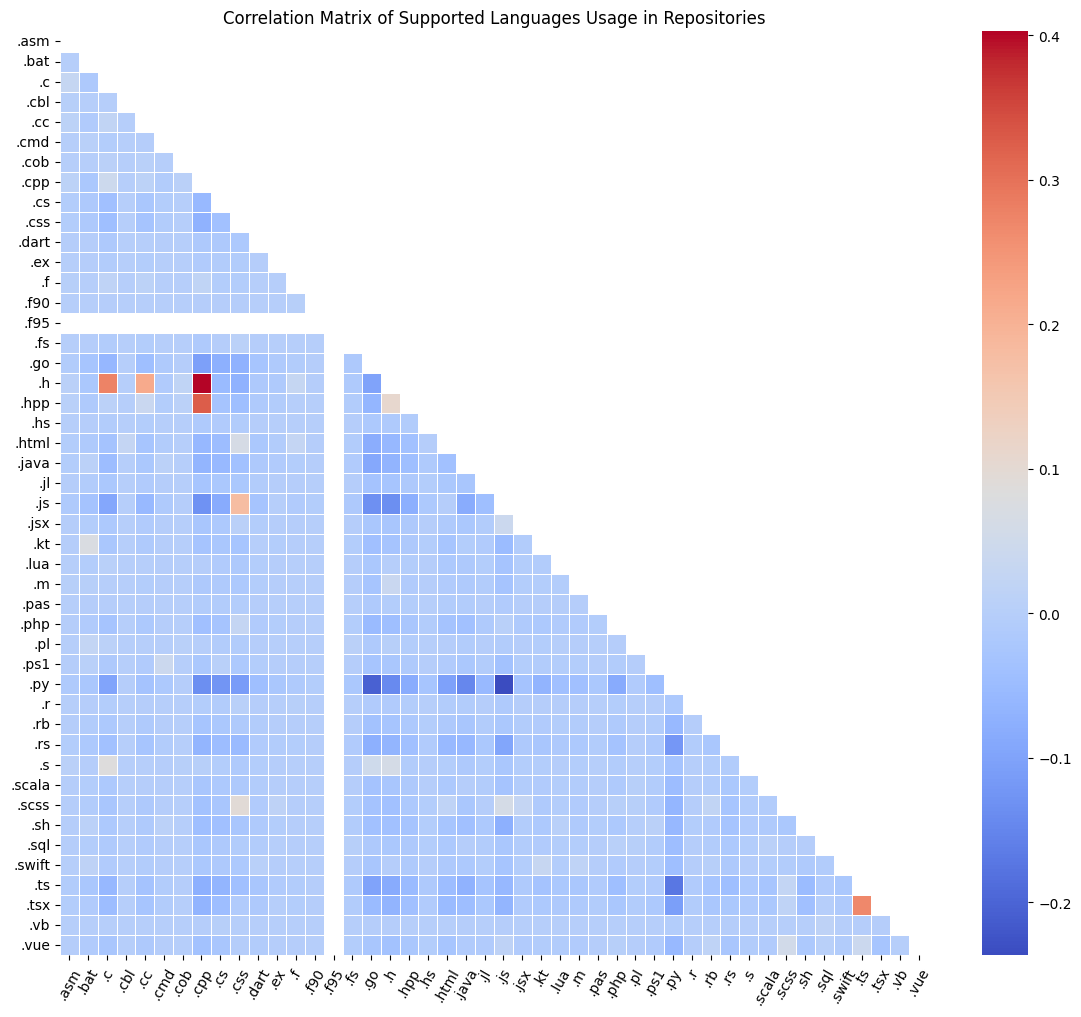

In [8]:
analytics.plot_language_correlation_matrix()

We can also display the percentages of the table we saw earlier in a nice plot.

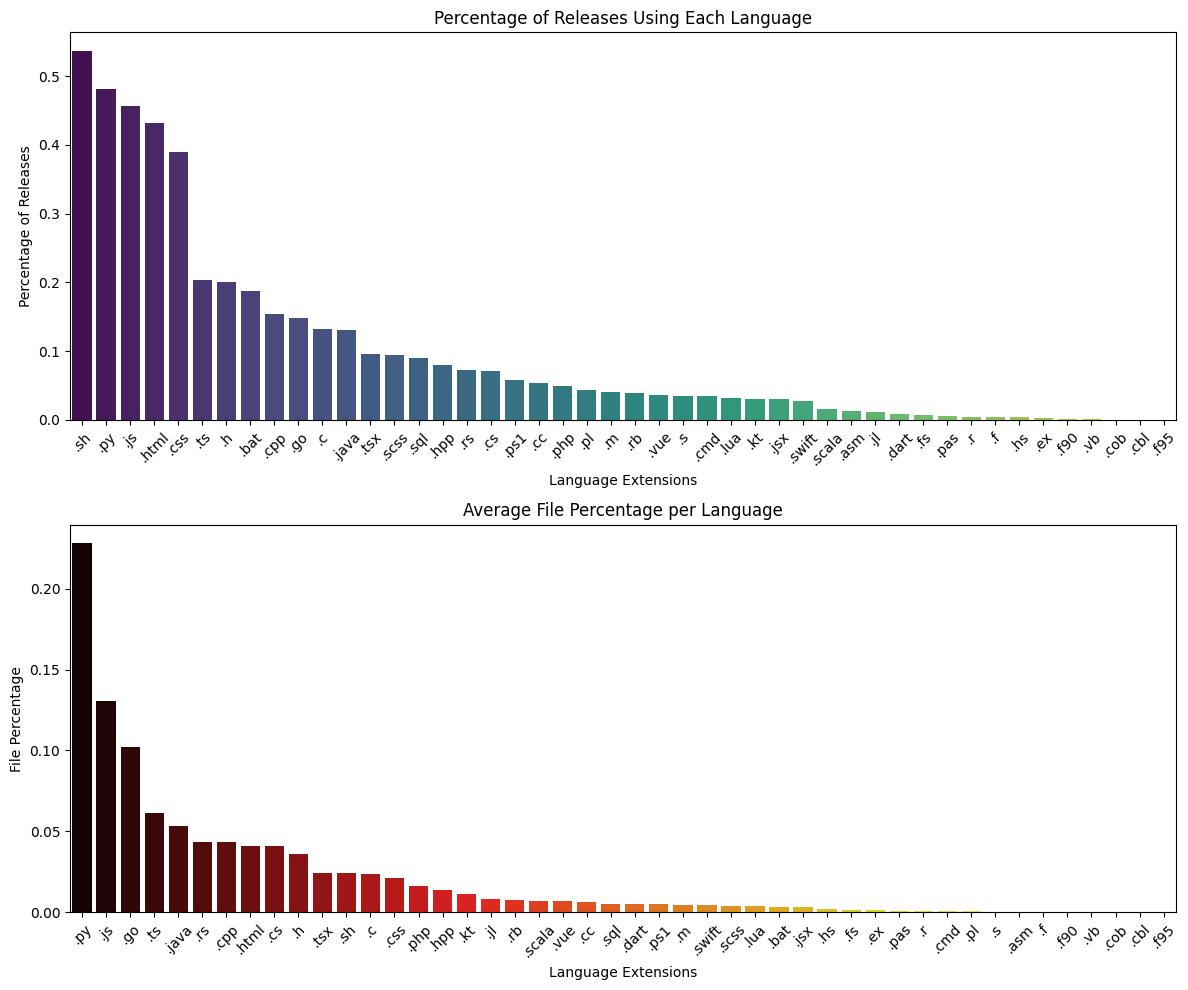

In [9]:
analytics.plot_language_percentage()

This let us visualize the evolution of languages' usage through time.

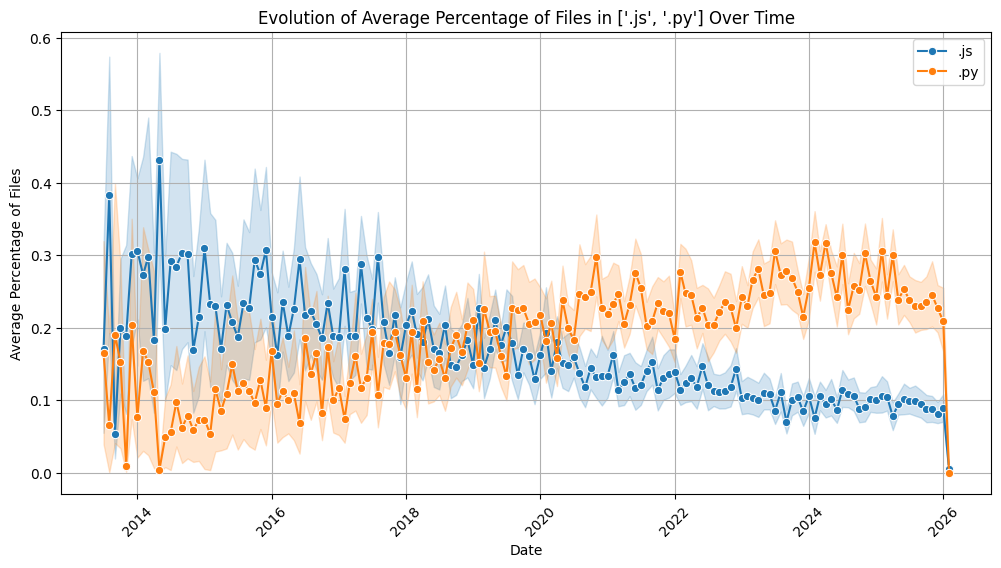

In [10]:
analytics.plot_language_evolution([".js", ".py"])

For instance, we can observe how the 10 least used languages have been used.

10 least used languages:
   language_extensions  language_usage_percentage
45                .f95                   0.000000
44                .cbl                   0.000019
43                .cob                   0.000152
42                 .vb                   0.000856
41                .f90                   0.001103
40                 .ex                   0.002834
39                 .hs                   0.003652
38                  .f                   0.004355
37                  .r                   0.004374
36                .pas                   0.005439


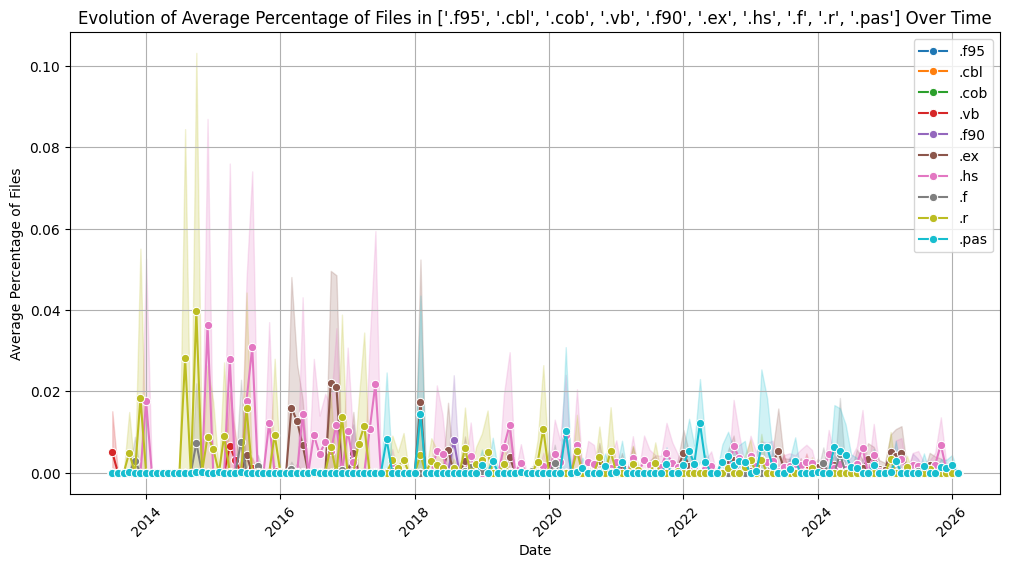

In [11]:
# Plot the 10 least used languages from the summary
least_used_languages = summary.sort_values(by="language_usage_percentage").head(10)
print("10 least used languages:")
print(least_used_languages[["language_extensions", "language_usage_percentage"]])

analytics.plot_language_evolution(least_used_languages["language_extensions"].tolist())

Changing the time interval for grouping data.

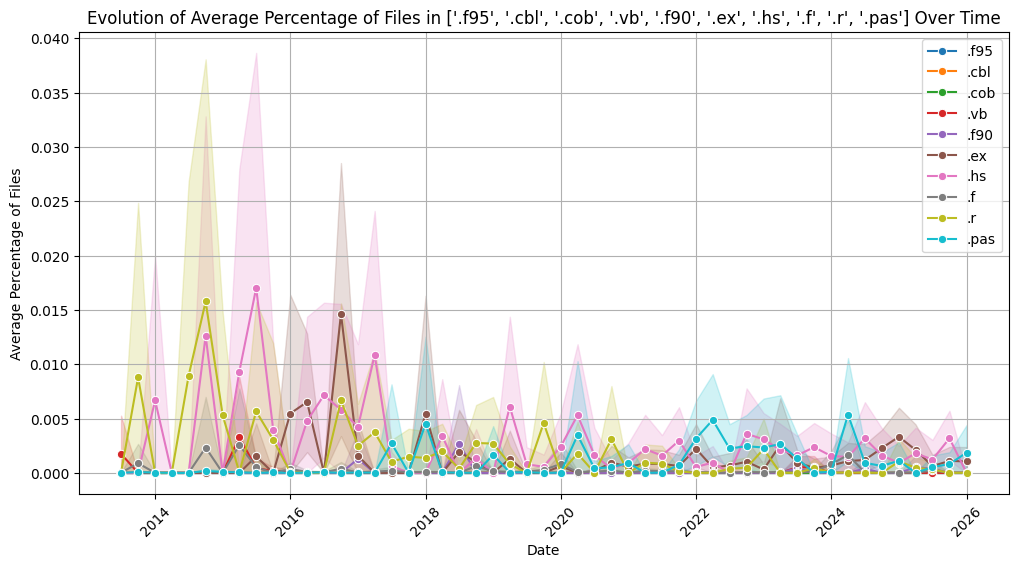

In [12]:
analytics.plot_language_evolution(least_used_languages["language_extensions"].tolist(), interval="Q")

Now, let's do the same thing with the 10 most used languages over time.

10 most used languages:
  language_extensions  language_usage_percentage
0                 .sh                   0.536820
1                 .py                   0.481400
2                 .js                   0.457018
3               .html                   0.432199
4                .css                   0.389254
5                 .ts                   0.203252
6                  .h                   0.201027
7                .bat                   0.187353
8                .cpp                   0.154089
9                 .go                   0.148383


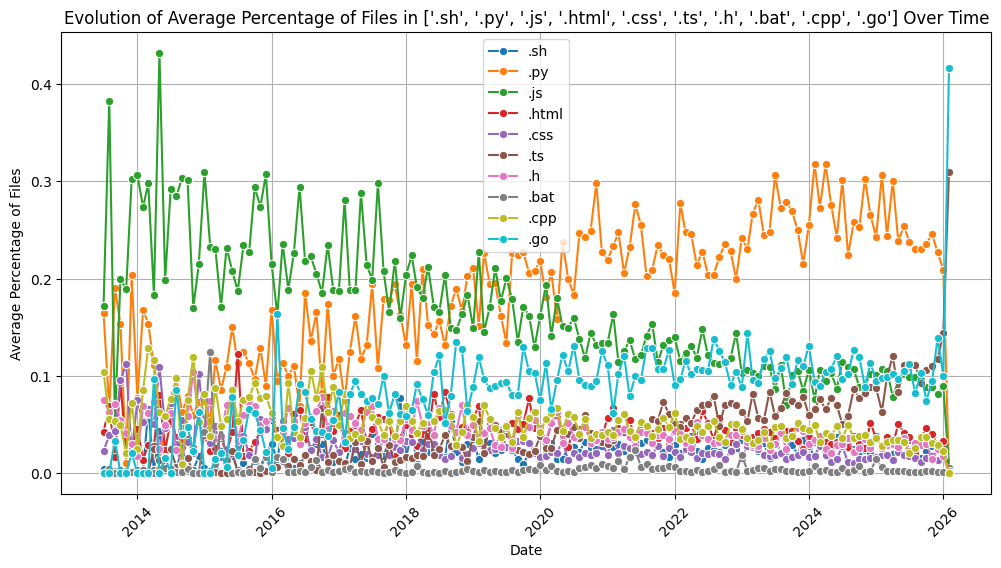

In [13]:
# Plot the 10 most used languages from the summary
most_used_languages = summary.sort_values(by="language_usage_percentage", ascending=False).head(10)
print("10 most used languages:")
print(most_used_languages[["language_extensions", "language_usage_percentage"]])

analytics.plot_language_evolution(most_used_languages["language_extensions"].tolist(), errorbar=None)

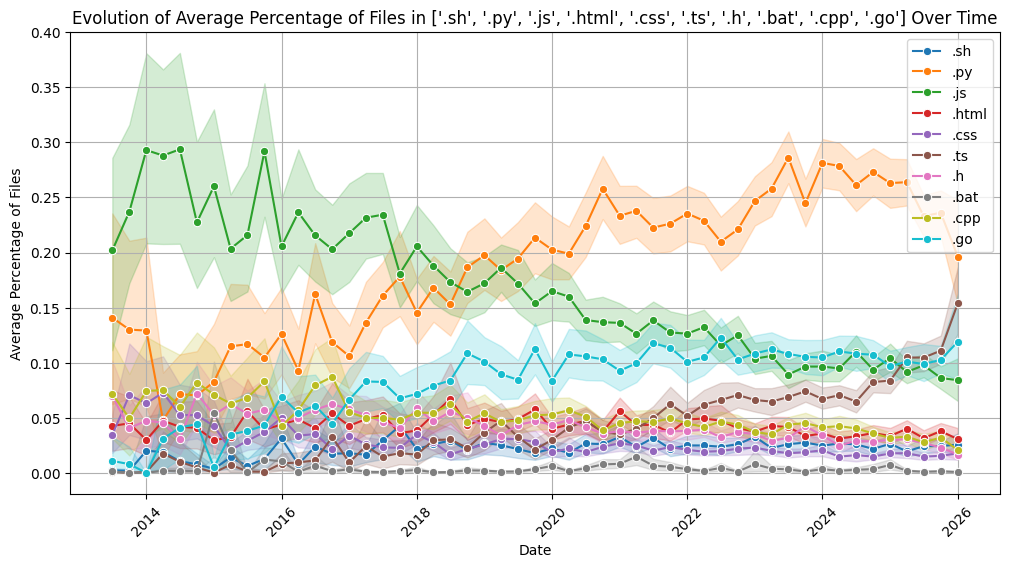

In [14]:
analytics.plot_language_evolution(most_used_languages["language_extensions"].tolist(), interval="Q")

This simply shows how many releases we retrieved for each time period.

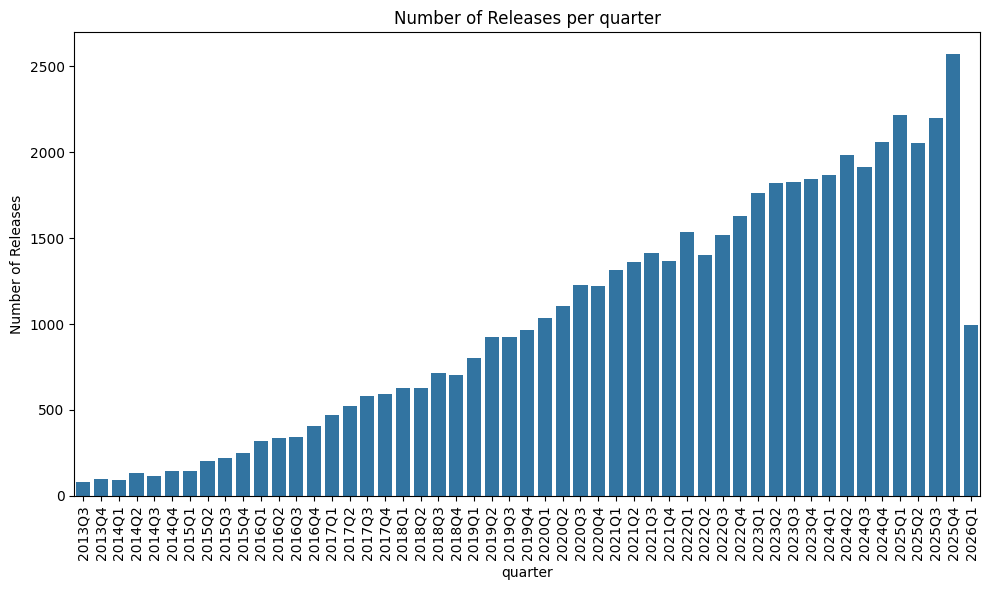

In [15]:
analytics.plot_releases_per_interval(interval="Q")

Finally, the most important part, the prediction of every languages using the Prophet library !

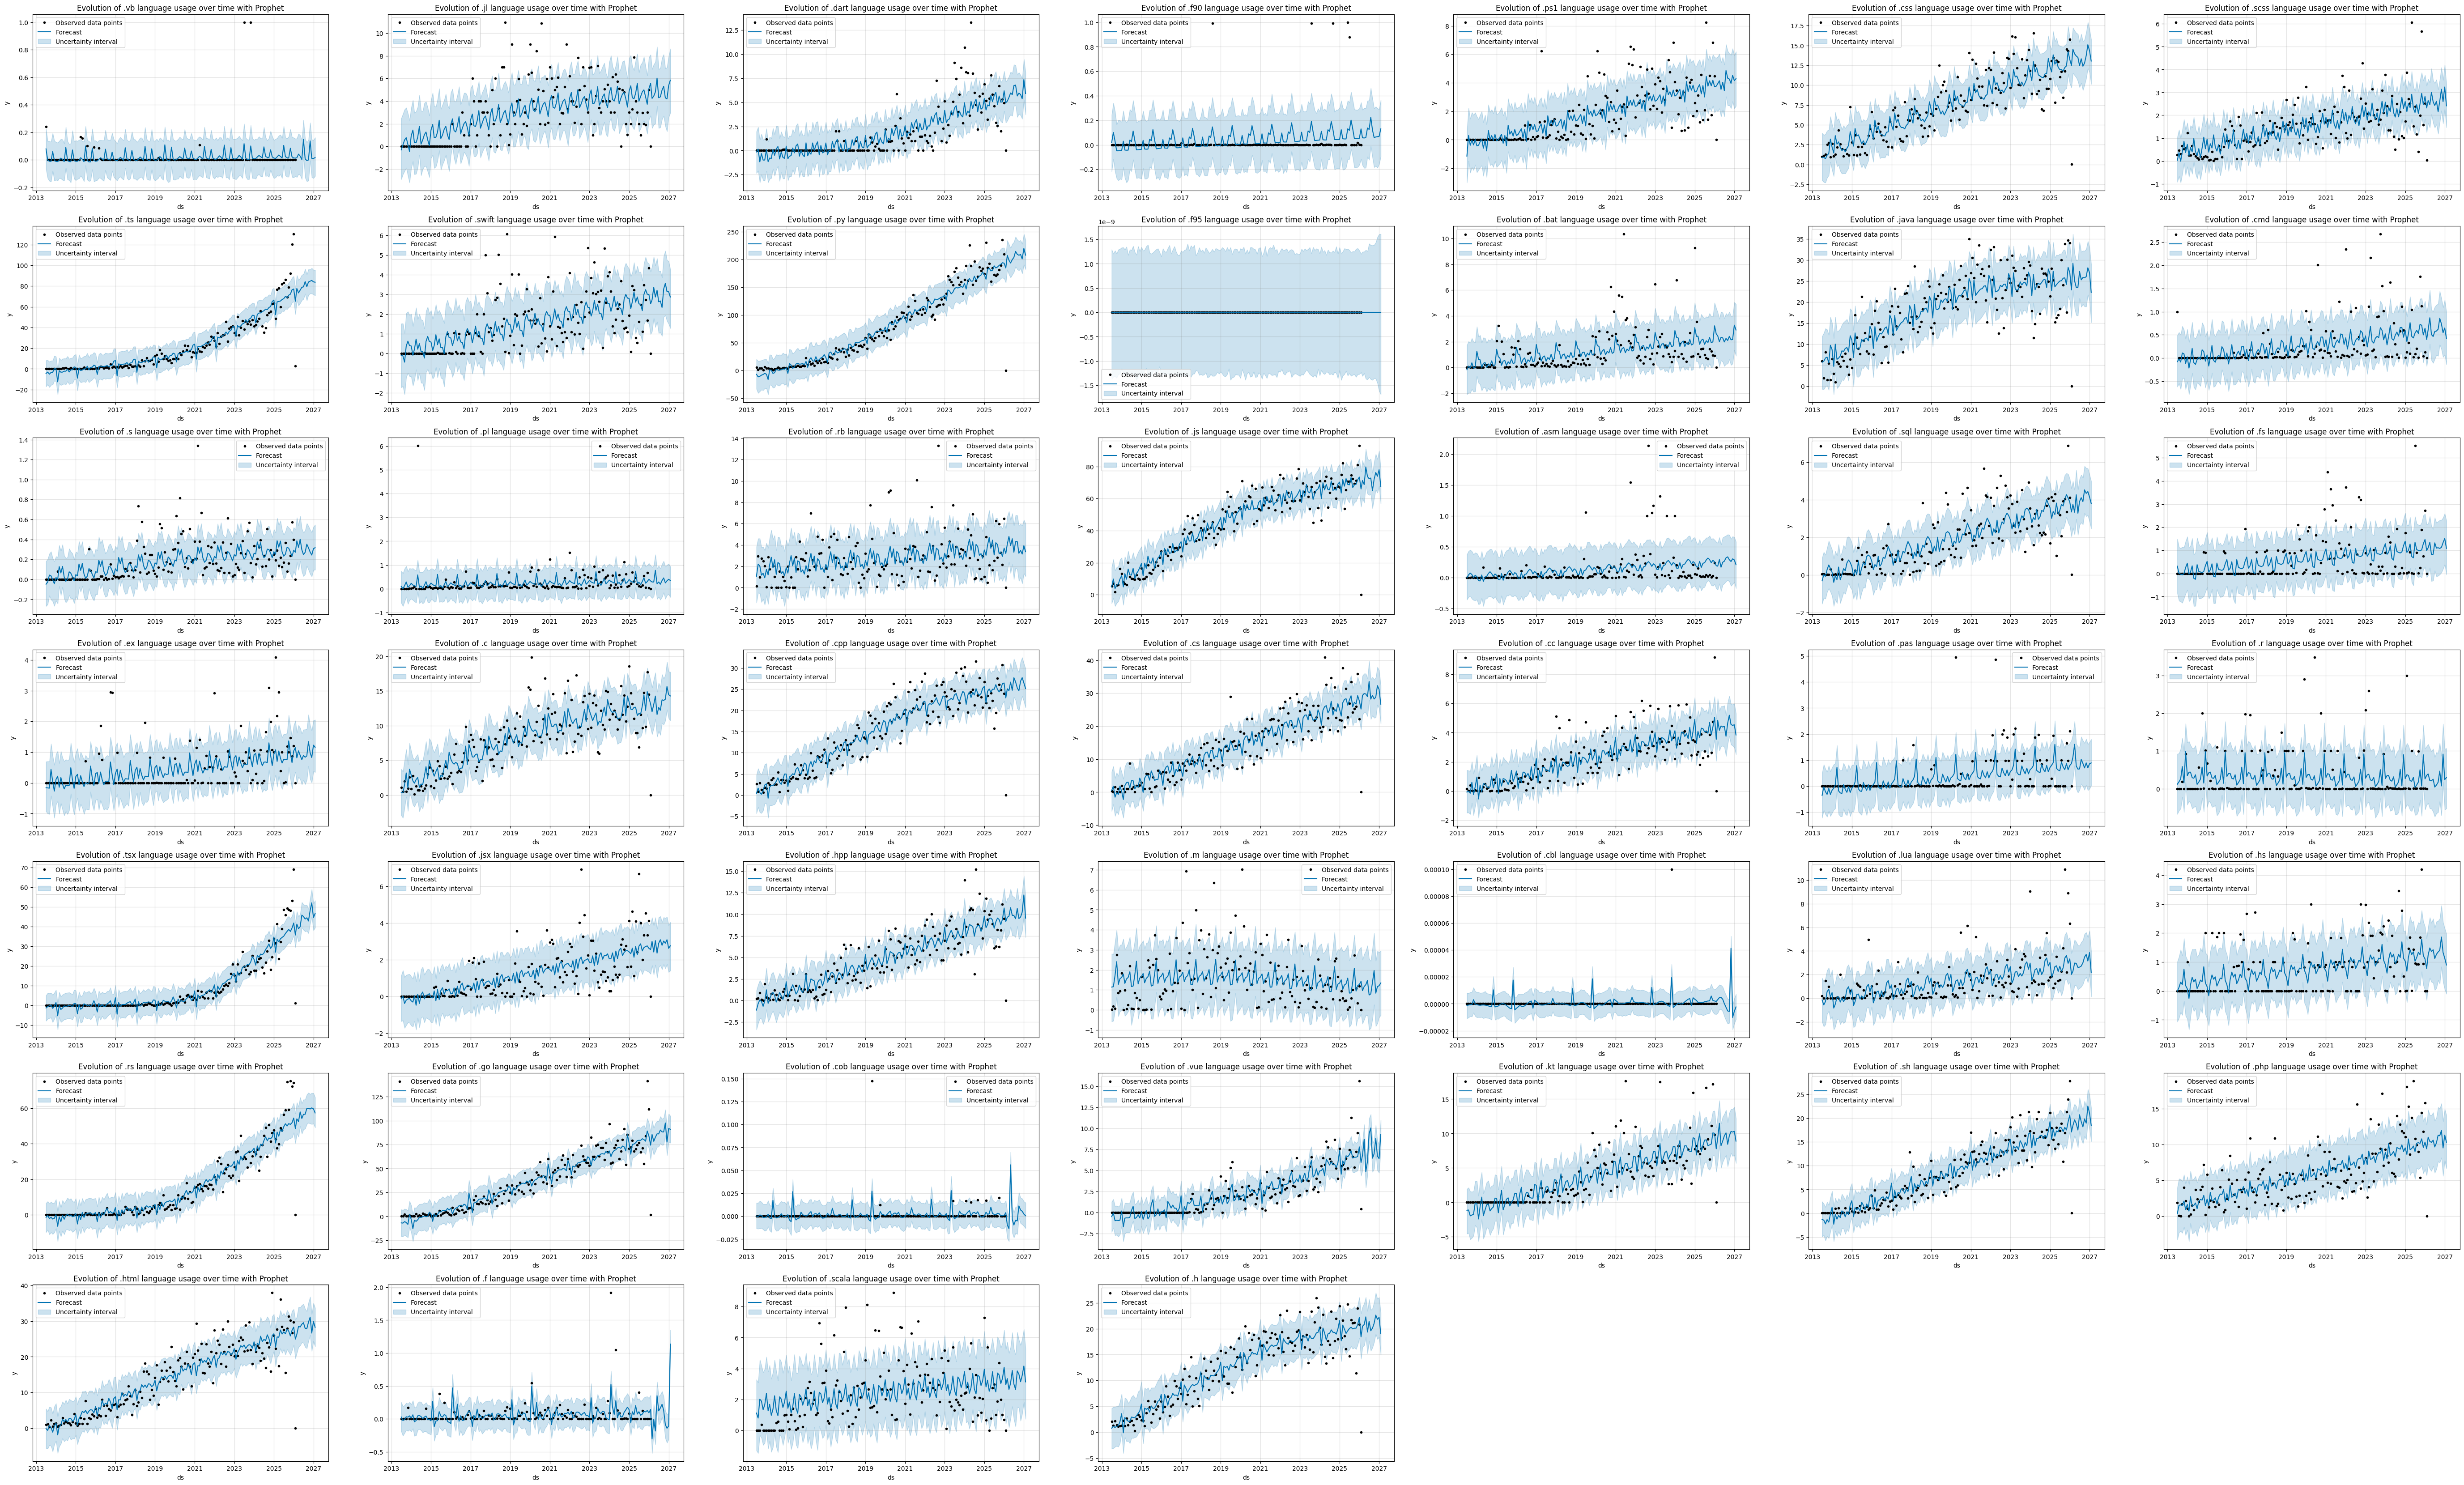

In [17]:
fig = analytics.plot_all_languages_predictions()